# New Section

In [8]:
import os
import cv2
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import tensorflow as tf
from tensorflow.keras import models, layers, callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.preprocessing.image import (ImageDataGenerator, load_img, img_to_array, array_to_img)
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,confusion_matrix, roc_curve, roc_auc_score)
import mediapipe as mp
from sklearn.utils import shuffle

from scipy.stats import spearmanr
from collections import Counter

In [9]:
# Initialize MediaPipe Hand detector
mp_hands = mp.solutions.hands
hands_detector = mp_hands.Hands(static_image_mode=True,max_num_hands=1,min_detection_confidence=0.5) #return keypoints only if confident

#Function to create 3 separate heatmaps (64x64) for different hand parts (Thumb, fingers and Palm+Wrist) starting from the rgb image 
def create_combined_heatmap(image_rgb, target_size=64, sigma=1.0):

    results = hands_detector.process(image_rgb)
    
    if not results.multi_hand_landmarks: #if no keypoints detected don't use the image
        return None
    
    # Initialize 3 separate heatmaps
    heatmap_thumb = np.zeros((target_size, target_size), dtype='float32')
    heatmap_fingers = np.zeros((target_size, target_size), dtype='float32')
    heatmap_palm = np.zeros((target_size, target_size), dtype='float32')
    
    hand_landmarks = results.multi_hand_landmarks[0] 
    
    x_grid, y_grid = np.meshgrid(np.arange(target_size), np.arange(target_size))
    
    for idx, landmark in enumerate(hand_landmarks.landmark):

        x_px = int(landmark.x * target_size) #convert coordinates to pixel
        y_px = int(landmark.y * target_size)
        
        x_px = np.clip(x_px, 0, target_size - 1)
        y_px = np.clip(y_px, 0, target_size - 1)
        
        gaussian = np.exp(-((x_grid - x_px)**2 + (y_grid - y_px)**2) / (2 * sigma**2)) #create gaussian heatmap for each keypoint
        
        # put the gaussian in the corresponding heatmap channel based on the keypoints index

        if idx == 0:
            heatmap_palm = np.maximum(heatmap_palm, gaussian)
        elif 1 <= idx <= 4:
            heatmap_thumb = np.maximum(heatmap_thumb, gaussian)
        else:
            heatmap_fingers = np.maximum(heatmap_fingers, gaussian)
    
    heatmaps = np.stack([heatmap_thumb, heatmap_fingers, heatmap_palm], axis=-1)   # Put together 3 heatmaps into a single array 64x64x3
    
    return heatmaps

AttributeError: module 'mediapipe' has no attribute 'solutions'

In [ ]:
# Function to preprocess image and generate RGB + heatmap channels

def preprocess_image_rgb_heatmap(image_path, target_size=64, heatmap_weight=1.0):

    try:

        img_rgb = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if img_rgb is None:
            return None
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
        
        # Resize while maintaining height-width ratio
        h, w = img_rgb.shape[:2]
        aspect_ratio = h / w
        
        if aspect_ratio > 1:
            new_w = int(target_size / aspect_ratio)
            img_resized = cv2.resize(img_rgb, (new_w, target_size))
        else:
            new_h = int(target_size * aspect_ratio)
            img_resized = cv2.resize(img_rgb, (target_size, new_h))
        
        # Add zero-padding to make square image
        canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)
        h_resized, w_resized = img_resized.shape[:2]
        y_offset = (target_size - h_resized) // 2
        x_offset = (target_size - w_resized) // 2
        canvas[y_offset:y_offset + h_resized, x_offset:x_offset + w_resized] = img_resized
        
        heatmaps = create_combined_heatmap(canvas, target_size)  # Extract 3-channel heatmap
        
        if heatmaps is None: #if no keypoints detected don't use the image
            return None
        
        if heatmap_weight != 1.0:
            heatmaps = np.clip(heatmaps * heatmap_weight, 0, 1) #Increase heatmap intensity
        
        rgb_normalized = canvas.astype('float32') / 255.0
        
        stacked = np.concatenate([rgb_normalized, heatmaps], axis=-1)  # Stack RGB channels and heatmap channels obtaining 6 channels (64x64x6)
        
        return stacked
        
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

In [ ]:
# Function to load images

def load_images_from_folders_with_heatmap(train_path, test_path, target_size=64, heatmap_weight=1.0):

    x_train = []
    y_train = []
    x_test = []
    y_test = []
    
    excluded_train = 0 #monitor excluded images
    excluded_test = 0

    preprocess_fn = lambda path: preprocess_image_rgb_heatmap(path, target_size, heatmap_weight)
    expected_channels = 6
    print(f"Channels: RGB (3) + Thumb/Fingers/Palm (3)")
    if heatmap_weight != 1.0:
        print(f"Heatmap boost: {heatmap_weight}x")
    
    character_folders = sorted([d for d in os.listdir(train_path) 
                                if os.path.isdir(os.path.join(train_path, d))])
    
    for class_idx, char_folder in enumerate(character_folders):
        train_char_path = os.path.join(train_path, char_folder)
        test_char_path = os.path.join(test_path, char_folder)
        
        # Load training images
        train_count = 0
        train_excluded = 0
        if os.path.exists(train_char_path):
            for img_file in os.listdir(train_char_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    img_path = os.path.join(train_char_path, img_file)
                    img = preprocess_fn(img_path)
                    if img is not None and img.shape == (target_size, target_size, expected_channels):
                        x_train.append(img)
                        y_train.append(class_idx)
                        train_count += 1
                    elif img is None:
                        train_excluded += 1
        
        # Load test images
        test_count = 0
        test_excluded = 0
        if os.path.exists(test_char_path):
            for img_file in os.listdir(test_char_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    img_path = os.path.join(test_char_path, img_file)
                    img = preprocess_fn(img_path)
                    if img is not None and img.shape == (target_size, target_size, expected_channels):
                        x_test.append(img)
                        y_test.append(class_idx)
                        test_count += 1
                    elif img is None:
                        test_excluded += 1
        
        excluded_train += train_excluded
        excluded_test += test_excluded
        
        status = ""
        if train_excluded > 0 or test_excluded > 0:
            status = f"Excluded: Train={train_excluded}, Test={test_excluded}"
        
        print(f"Class {class_idx:2d} ({char_folder}): Train={train_count:4d} | Test={test_count:4d}{status}")
    
    if len(x_train) == 0 or len(x_test) == 0:
        raise ValueError("No images found")
    
    x_train = np.array(x_train)
    x_test = np.array(x_test)
    y_train = np.array(y_train)
    y_test = np.array(y_test)
    
    print(f"\nTraining set: {x_train.shape} images")
    print(f"Test set: {x_test.shape} images")
    print(f"Classes: {len(np.unique(y_train))}")
    
    if excluded_train > 0 or excluded_test > 0:
        print(f"\nTotal excluded (no keypoints): Train={excluded_train}, Test={excluded_test}")
    
    num_classes = len(character_folders)
    y_train = to_categorical(y_train, num_classes=num_classes) #one-hot encode labels
    y_test = to_categorical(y_test, num_classes=num_classes)
    
    return x_train, x_test, y_train, y_test

In [ ]:
train_folder = "asl_alphabet_train"
test_folder = "asl_alphabet_test"

x_train, x_test, y_train, y_test = load_images_from_folders_with_heatmap(train_folder, test_folder, target_size=64)

✓ Found training folder: asl_alphabet_train
✓ Found test folder: asl_alphabet_test
🎨 Mode: RGB + Multi-Heatmap (6 channels)
   └─ Channels: RGB (3) + Thumb/Fingers/Palm (3)
Found 26 character classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
⚠️  Images without detected keypoints will be EXCLUDED from dataset
📍 Using sigma=1.0 for keypoint localization

Class  0 (A): Train=1172 | Test= 115 | ❌ Excluded: Train=223, Test=0
Class  1 (B): Train=1139 | Test= 115 | ❌ Excluded: Train=256, Test=0
Class  2 (C): Train=1228 | Test=  97 | ❌ Excluded: Train=347, Test=18
Class  3 (D): Train=1284 | Test= 115 | ❌ Excluded: Train=159, Test=0
Class  4 (E): Train=1220 | Test= 115 | ❌ Excluded: Train=189, Test=0
Class  5 (F): Train=1293 | Test= 115 | ❌ Excluded: Train=79, Test=0
Class  6 (G): Train=1221 | Test= 104 | ❌ Excluded: Train=161, Test=11
Class  7 (H): Train=1267 | Test= 115 | ❌ Excluded: Train=128, Test=0
Cl

In [ ]:
x_train, y_train = shuffle(x_train, y_train, random_state=17)
x_test, y_test = shuffle(x_test, y_test, random_state=17)

#Training/Validation split
val_split = int(len(x_train) * 0.2)

x_train_final = x_train[:-val_split]
y_train_final = y_train[:-val_split]

x_val = x_train[-val_split:]
y_val = y_train[-val_split:]

x_test_final = x_test
y_test_final = y_test


print(f"  Train:      {x_train_final.shape[0]} images")
print(f"  Validation: {x_val.shape[0]} images")
print(f"  Test:       {x_test_final.shape[0]} images")
print(f"  Total:      {x_train_final.shape[0] + x_val.shape[0] + x_test_final.shape[0]} images")


✓ Data split complete:
  Train:      25294 images
  Validation: 5420 images
  Test:       2925 images (held out, never used during training)
  Total:      33639 images


In [ ]:
# Define a number for each letter A-Z
map_characters = {i: chr(65 + i) for i in range(26)}  # A-Z
print("Character mapping:", map_characters)

num_output_classes = y_train_final.shape[1]
print(f"Number of classes in training data: {num_output_classes}")

# Clear any previous model
gc.collect()

Character mapping: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z'}


In [ ]:
#Build the CNN model
#Input shape: 64x64x6
#3 convolutional blocks: 64 → 128 → 128 filters with Max pooling, batch normalization and dropout
#GlobalAveragePooling2D as pooling layer before dense layers
#2 dense layers

model = Sequential([
    # Block 1: 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 6), kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding="same", kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.MaxPool2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 2: 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding="same", kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding="same", kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.MaxPool2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 3: 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding="same", kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding="same", kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.MaxPool2D((2, 2)),
    layers.Dropout(0.25),
    
    # Global Average Pooling (8x8x128 → 128 features)
    layers.GlobalAveragePooling2D(),
    
    # Dense layers
    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    layers.Dense(num_output_classes, activation='softmax', kernel_initializer='glorot_uniform')
])

print("\nFinal CNN Architecture:")
print("  Encoder: Conv2D(64) --> Conv2D(128) --> Conv2D(128)")
print("  Pooling: GlobalAveragePooling2D (8x8x128 --> 128 features)")
print("  Decoder: Dense(256) --> Dense(26)")
print("  Parameters: ~600K")
print("  Initializer: He Normal")


c:\Users\nicol\.venv11\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'num_output_classes' is not defined

In [115]:

model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 64, 64, 64)     │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_68          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_70          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 599,194 (2.29 MB)

 Trainable params: 597,402 (2.28 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# Training Configuration

classes = num_output_classes
epochs = 50
adam = Adam(learning_rate=0.001)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = callbacks.EarlyStopping( #Stop training if no improvement in validation loss for 10 consecutive epochs
    monitor='val_loss',
    patience=10,
    min_delta=0.01,  
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau( #Reduce learning rate if validation loss plateaus
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_delta=0.005,  
    min_lr=1e-7,
    verbose=1
)

print("\nStarting training...\n")

history = model.fit(
    x_train_final, y_train_final,
    batch_size=32,
    epochs=epochs,
    verbose=2,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, reduce_lr],
)


NameError: name 'num_output_classes' is not defined

In [7]:
def plot_loss(epochs, loss, val_loss):
    plt.plot(epochs, loss, 'bo', label='Training Loss')
    plt.plot(epochs, val_loss, 'orange', label = 'Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()


def plot_accuracy(epochs, acc, val_acc):
    plt.plot(epochs, acc, 'bo', label='Training accuracy')
    plt.plot(epochs, val_acc, 'orange', label = 'Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.show()

In [10]:
class_labels = list(map_characters.values())

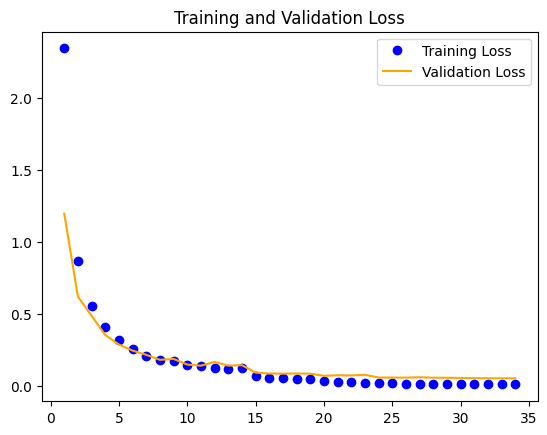

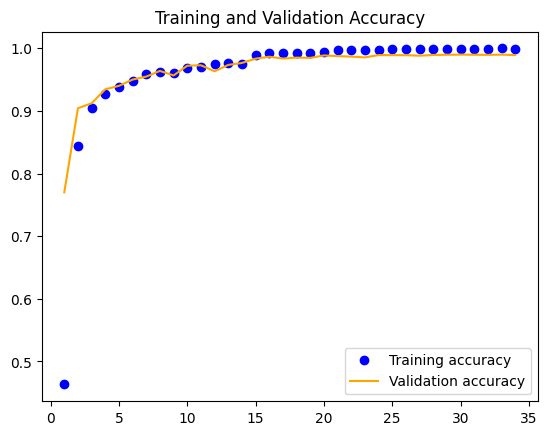

In [11]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plot_loss(range(1, len(loss) + 1), loss, val_loss)
plot_accuracy(range(1, len(loss) + 1), acc, val_acc)

EVALUATION ON HELD-OUT TEST SET (never seen during training)

✓ Test Accuracy: 0.7897 (78.97%)
✓ Test Loss: 1.3320

Classification Report:
              precision    recall  f1-score   support

           A       0.97      0.97      0.97       115
           B       1.00      1.00      1.00       115
           C       0.75      0.99      0.85        97
           D       0.95      0.73      0.83       115
           E       0.44      1.00      0.61       115
           F       0.94      1.00      0.97       115
           G       0.00      0.00      0.00       104
           H       0.79      1.00      0.88       115
           I       0.86      0.99      0.92       115
           J       0.87      0.30      0.44       115
           K       0.99      0.98      0.99       115
           L       1.00      1.00      1.00       115
           M       0.00      0.00      0.00       100
           N       1.00      0.61      0.76       115
           O       0.85      0.41      0.56       

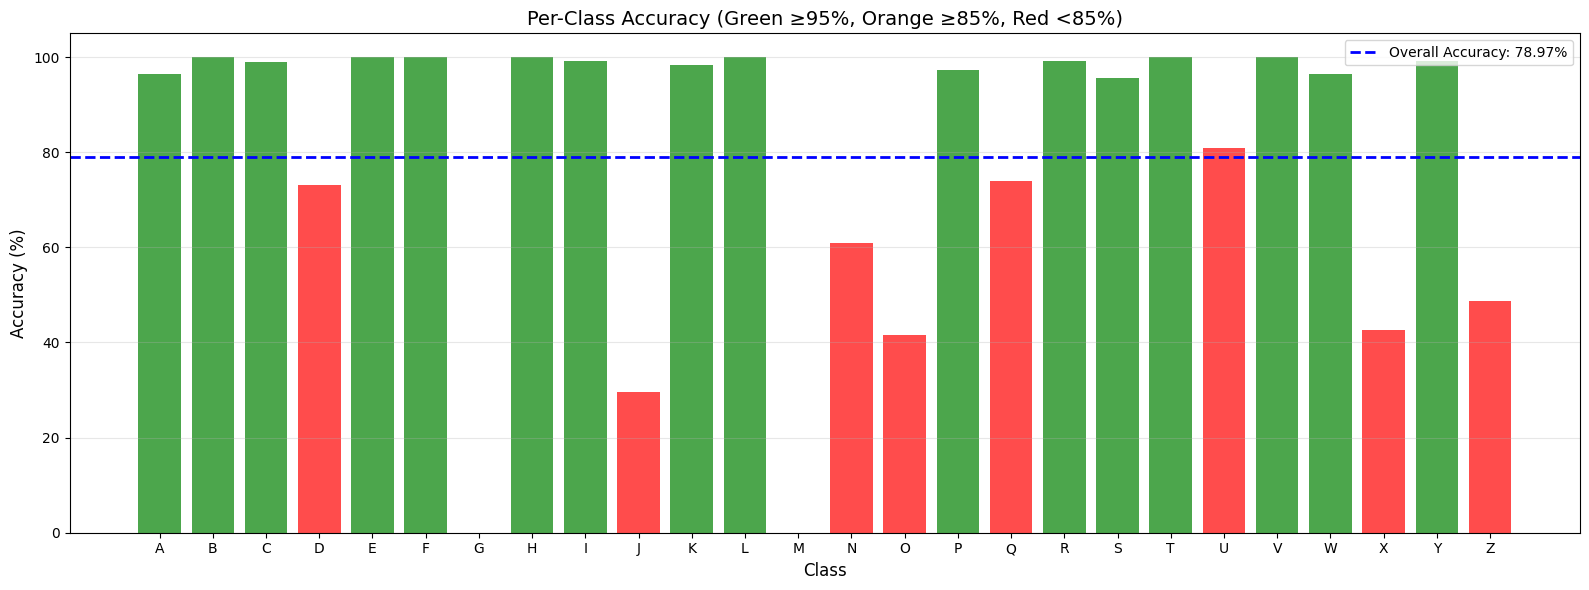

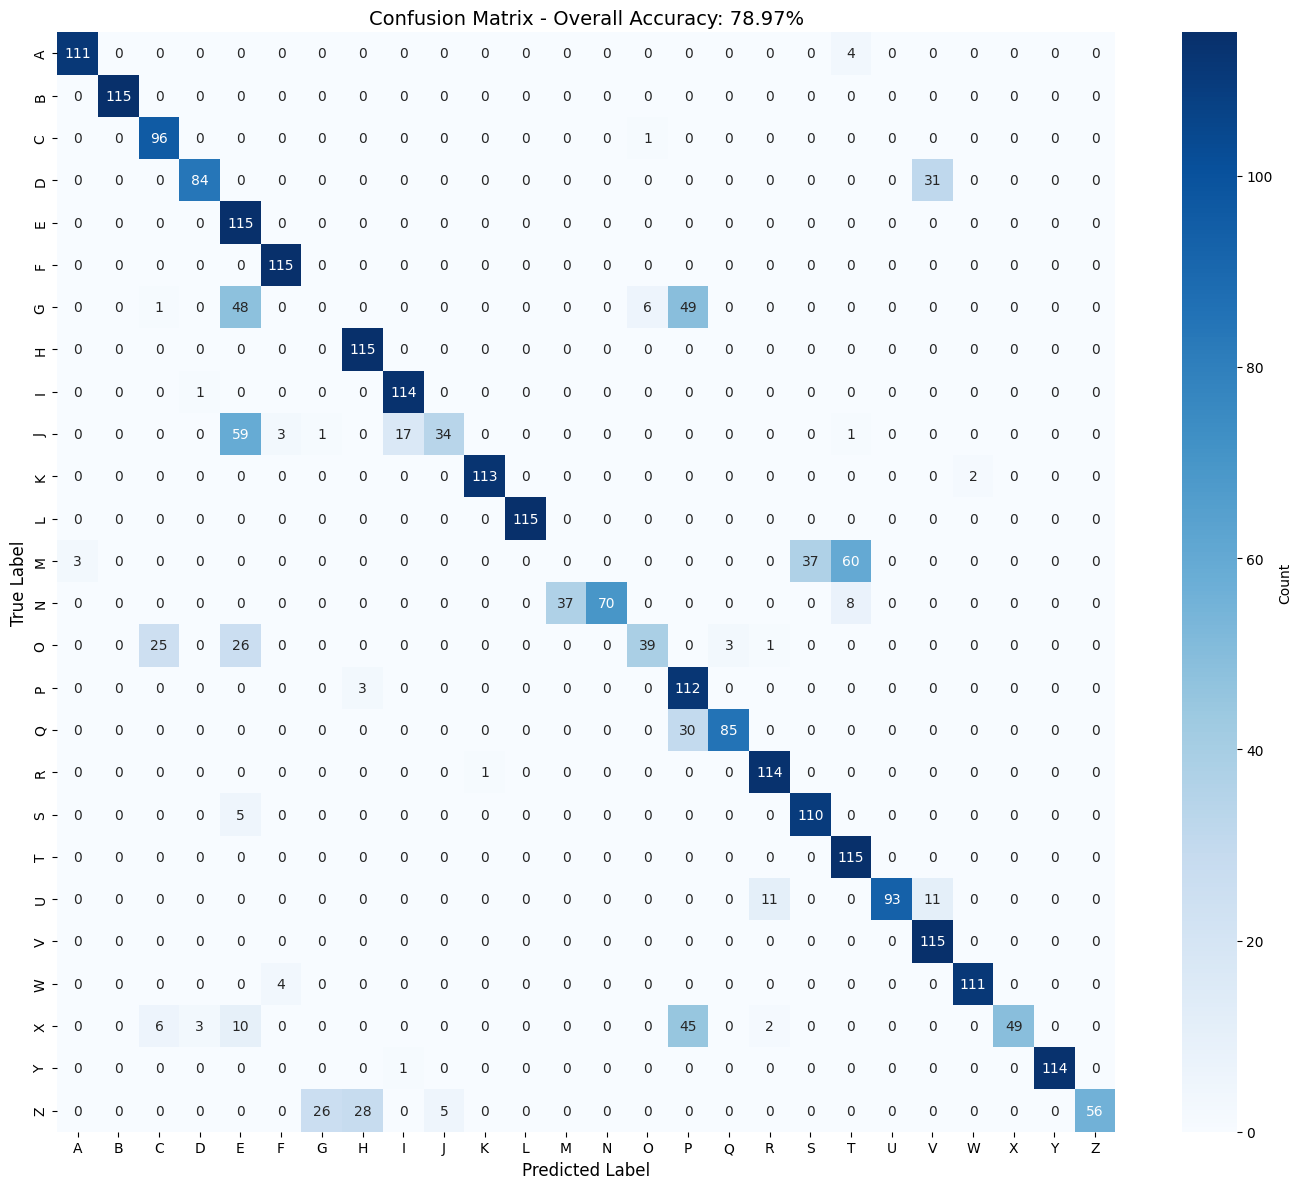

In [ ]:
#Evaluation  on final test set

train_path = 'asl_alphabet_train'
test_path = 'asl_alphabet_test'

class_labels = sorted([d for d in os.listdir(train_path) 
                       if os.path.isdir(os.path.join(train_path, d))])


score = model.evaluate(x_test_final, y_test_final, verbose=0)
print(f'\nTest Accuracy: {score[1]:.4f} ({score[1]*100:.2f}%)')
print(f'Test Loss: {score[0]:.4f}\n')

y_pred = model.predict(x_test_final, verbose=0)
Y_pred_classes = np.argmax(y_pred, axis=1)
Y_true = np.argmax(y_test_final, axis=1)

# Classification Report
report = metrics.classification_report(Y_true, Y_pred_classes, target_names=class_labels)
print("Classification Report:")
print(report)

# Per-class accuracy

print("PER-CLASS ACCURACY BREAKDOWN")


per_class_accuracy = []
for i, label in enumerate(class_labels):
    mask = Y_true == i
    if mask.sum() > 0:
        accuracy = (Y_pred_classes[mask] == Y_true[mask]).mean()
        per_class_accuracy.append(accuracy)

        emoji = "Good" if accuracy >= 0.95 else "Mid" if accuracy >= 0.7 else "Bad"
        print(f"{emoji} {label:3s}: {accuracy*100:6.2f}% ({mask.sum():4d} samples)")
    else:
        per_class_accuracy.append(0)
        print(f" {label:3s}:   0.00% (no samples)")

print(f"Average per-class accuracy: {np.mean(per_class_accuracy)*100:.2f}%")
print(f"Worst performing class: {class_labels[np.argmin(per_class_accuracy)]} ({np.min(per_class_accuracy)*100:.2f}%)")
print(f"Best performing class: {class_labels[np.argmax(per_class_accuracy)]} ({np.max(per_class_accuracy)*100:.2f}%)")

In [ ]:
#Plot accuracy per-class

plt.figure(figsize=(16, 6))
colors = ['green' if acc >= 0.95 else 'orange' if acc >= 0.85 else 'red' 
          for acc in per_class_accuracy]
plt.bar(class_labels, np.array(per_class_accuracy)*100, color=colors, alpha=0.7)
plt.axhline(y=score[1]*100, color='blue', linestyle='--', linewidth=2, label=f'Overall Accuracy: {score[1]*100:.2f}%')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Class Accuracy (Green ≥95%, Orange ≥85%, Red <85%)', fontsize=14)
plt.xticks(rotation=0, fontsize=10)
plt.ylim([0, 105])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix
cm = confusion_matrix(Y_true, Y_pred_classes)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - Overall Accuracy: {score[1]*100:.2f}%', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
model.save('ASL_predictormemecambioheatmapFINALE.keras')

✓ Modello salvato come 'ASL_predictormeme65.keras'


In [ ]:
#Conformal prediction adapted to CNN: Split Conformal Prediction with Softmax

X_test = x_test

if len(y_test.shape) > 1:
    if y_test.shape[1] > 1:
        y_test_flat = np.argmax(y_test, axis=1)
    else:
        y_test_flat = y_test.flatten()
else:
    y_test_flat = y_test


# Get softmax predictions function
def get_softmax_predictions(X):
    predictions = model.predict(X, verbose=0)
    predictions = predictions / predictions.sum(axis=1, keepdims=True)
    return predictions

#Split test set into calibration and final test sets

X_calib, X_test_final, y_calib, y_test_final = train_test_split(X_test, y_test_flat, test_size=0.5, random_state=42, stratify=y_test_flat)
print(f"   Calibration set: {X_calib.shape[0]} samples")
print(f"   Final test set: {X_test_final.shape[0]} samples")

#Store softmax for calibration set
softmax_calib = get_softmax_predictions(X_calib)

# Get list of classes
classes_list = sorted(np.unique(y_test_flat))
n_classes = len(classes_list)

# Compute nonconformity scores (1 - softmax(true_class))
nonconformity_scores_calib = []
for i in range(len(y_calib)):
    true_class_idx = int(y_calib[i])
    prob_true_class = softmax_calib[i, true_class_idx]
    nonconf_score = 1 - prob_true_class
    nonconformity_scores_calib.append(nonconf_score)

nonconformity_scores_calib = np.array(nonconformity_scores_calib)
print(f"   Score range: [{nonconformity_scores_calib.min():.4f}, {nonconformity_scores_calib.max():.4f}]")
print(f"   Mean score: {nonconformity_scores_calib.mean():.4f}")

#Compute quantile for desired α

alpha = 0.1

n = len(nonconformity_scores_calib)

# Conformal quantile formula: int((n+1)(1-α))/n
q_level = np.ceil((n + 1) * (1 - alpha)) / n
q_level = min(q_level, 1.0) #at most 1
quantile = np.quantile(nonconformity_scores_calib, q_level)

print(f"   Quantile threshold: {quantile:.4f}")

#Prediction sets on final test set

# Get softmax predictions for final test set
softmax_test = get_softmax_predictions(X_test_final)

def build_prediction_sets(softmax_probs, quantile, n_classes):
    prediction_sets = []
    point_predictions = []
    
    for probs in softmax_probs:
        pred_set = []
        
        # Check each class
        for class_idx in range(n_classes):
            nonconf_score = 1 - probs[class_idx]
            if nonconf_score <= quantile:
                pred_set.append(class_idx)
        
        if len(pred_set) == 0:
            # Include the class with highest probability
            best_idx = np.argmax(probs)
            pred_set = [best_idx]
        
        prediction_sets.append(pred_set)
        
        # Point prediction: argmax
        point_pred_idx = np.argmax(probs)
        point_predictions.append(point_pred_idx)
    
    return prediction_sets

y_pred_conf, pred_sets = build_prediction_sets(softmax_test, quantile, n_classes)
y_pred_conf = np.array(y_pred_conf)

print(f"   Prediction sets built for {len(pred_sets)} samples")

In [ ]:
#Evaluation of conformal prediction results

print(f"SPLIT CONFORMAL PREDICTION RESULTS (α = {alpha})")

# Coverage (proportion of times true class is in prediction set)
coverage_list = [1 if y_test_final[i] in pred_sets[i] else 0 
                 for i in range(len(y_test_final))]
avg_coverage = np.mean(coverage_list)
coverage_gap = (avg_coverage - (1 - alpha)) * 100

print(f"   Average Coverage: {avg_coverage*100:.2f}%")

# Cardinality (size of prediction sets)
cardinalities = [len(pred_set) for pred_set in pred_sets]
avg_cardinality = np.mean(cardinalities)
efficiency = (1 - (avg_cardinality - 1) / (n_classes - 1)) * 100

print(f"\n CARDINALITY:")
print(f"   Average Set Size: {avg_cardinality:.2f}")
print(f"   Min Set Size: {min(cardinalities)}")
print(f"   Max Set Size: {max(cardinalities)}")

# Per-class metrics
print(f"\n PER-CLASS METRICS:")
print(f"   {'Class':<6} {'Coverage':<10} {'Avg Size':<10} {'Samples':<8}")
for cls_idx in classes_list:
    mask = y_test_final == cls_idx
    n_samples = np.sum(mask)
    if n_samples > 0:
        cls_coverage = np.mean([1 if cls_idx in pred_sets[i] else 0 
                                for i in range(len(y_test_final)) if mask[i]])
        cls_cardinality = np.mean([len(pred_sets[i]) 
                                   for i in range(len(y_test_final)) if mask[i]])
        print(f"   {cls_idx:<6} {cls_coverage*100:>6.1f}%    {cls_cardinality:>6.2f}     {n_samples:<8}")


print("EXAMPLES OF PREDICTION SETS (First 20 samples)")

print(f"{'#':<4} {'True':<5} {'Pred':<5} {'✓':<2} {'Prediction Set':<40} {'Size':<5} {'Covered':<8}")

n_examples = min(20, len(X_test_final))
for i in range(n_examples):
    true_class = int(y_test_final[i])
    point_pred = int(y_pred_conf[i])
    pred_set = [int(x) for x in pred_sets[i]]
    correct = "✓" if point_pred == true_class else "✗"
    in_set = "✓" if true_class in pred_set else "✗"
    
    set_str = str(sorted(pred_set))
    if len(set_str) > 38:
        set_str = set_str[:35] + "..."
    
    print(f"{i+1:<4} {true_class:<5} {point_pred:<5} {correct:<2} {set_str:<40} {len(pred_set):<5} {in_set:<8}")

#Distribution of prediction set sizes


print("DISTRIBUTION OF PREDICTION SET SIZES")

size_dist = Counter(cardinalities)
max_count = max(size_dist.values())
for size in sorted(size_dist.keys()):
    count = size_dist[size]
    pct = count / len(cardinalities) * 100
    bar_length = int((count / max_count) * 40)
    print(f"Size {size:2d}: {count:4d} samples ({pct:5.1f}%)")